<a href="https://colab.research.google.com/github/MaryumAkram16/machine-learning-assignments/blob/main/ecommerce_sales_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total_Sales_USD        1.000000
Marketing_Spend_USD    0.983553
Name: Total_Sales_USD, dtype: float64


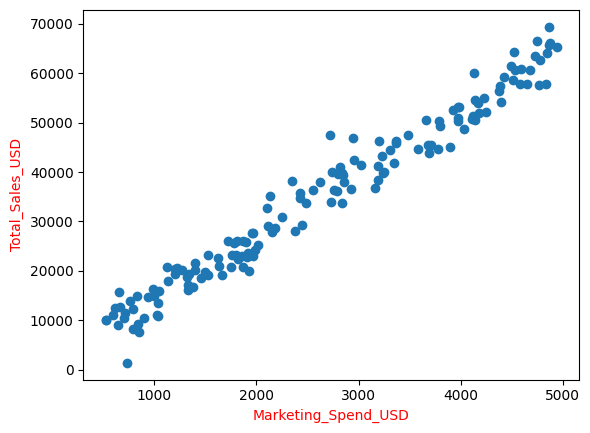

R² for each fold: [0.98585909 0.94409747 0.94976362 0.97512567 0.96668213]
Mean R²: 0.9643055966251117
Std dev: 0.015537777289580595

Final Coefficient: [12.6166045]
Final Intercept: 1834.137953455349
Predicted sales for $1000 spend: 14450.742455167703


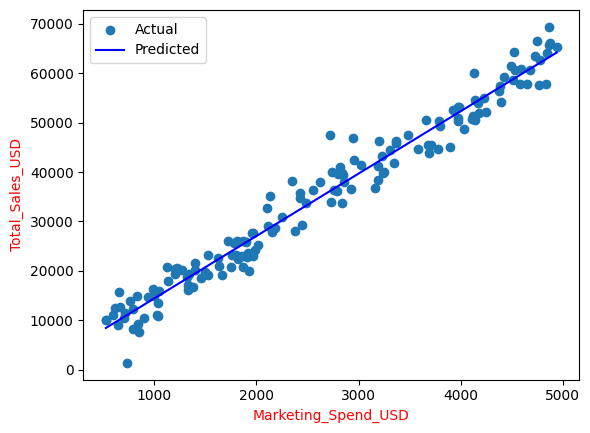

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv("/content/drive/MyDrive/ecommerce_sales_data.csv")
df.head()
# Quick look at correlations with the target — helps decide if other
# features are worth including in the model
print(df.corr(numeric_only=True)['Total_Sales_USD'].sort_values(ascending=False))
# Visualize raw relationship before fitting anything
plt.xlabel("Marketing_Spend_USD", color="red")
plt.ylabel("Total_Sales_USD", color="red")
plt.scatter(df.Marketing_Spend_USD, df.Total_Sales_USD)
plt.show()

from sklearn.model_selection import cross_val_score, KFold

# Cross-validation instead of a single train/test split —
# gives a more reliable estimate of how well the model generalizes
X = df[['Marketing_Spend_USD']]
y = df['Total_Sales_USD']

lr = linear_model.LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lr, X, y, cv=kf, scoring='r2')

print("R² for each fold:", cv_scores)
print("Mean R²:", cv_scores.mean())
print("Std dev:", cv_scores.std())

# Fit final model on the FULL dataset for predictions/coefficients
lr.fit(X, y)
print("\nFinal Coefficient:", lr.coef_)
print("Final Intercept:", lr.intercept_)

# Predict for a new value — pass a DataFrame with matching column names
new_spend = pd.DataFrame([[1000]], columns=['Marketing_Spend_USD'])
predicted = lr.predict(new_spend)
print("Predicted sales for $1000 spend:", predicted[0])

# Visualize the fitted line against the FULL dataset
plt.xlabel("Marketing_Spend_USD", color="red")
plt.ylabel("Total_Sales_USD", color="red")
plt.scatter(df.Marketing_Spend_USD, df.Total_Sales_USD, label="Actual")
plt.plot(
    df.Marketing_Spend_USD.sort_values(),
    lr.predict(df[['Marketing_Spend_USD']].sort_values('Marketing_Spend_USD')),
    color="blue",
    label="Predicted"
)
plt.legend()
plt.show()